# EViT — Training su UNI (wrapper approach)

Adatta il metodo **EViT** (*Efficient Vision Transformers*) al classificatore UNI LoRA
tramite wrapper, senza modificare la classe backbone.

## Come funziona EViT

EViT seleziona i token a ogni layer di pruning usando l'**attenzione del CLS token** verso i patch
token (media tra le teste). I token con attenzione più alta vengono mantenuti; i rimanenti
vengono opzionalmente fusi in un unico *fused token* pesato per attenzione.

**Nessun modulo learnable aggiuntivo** — a differenza di DynamicViT non ci sono PredictorLG.
La logica di pruning è deterministica e si basa sull'attenzione calcolata normalmente.

## Strategia di training

- Il modello si addestra con **fine-tuning standard** (CE + label smoothing)
- Il `keep_rate` viene **schedulato** con cosine annealing: parte da 1.0 (nessun pruning)
  e scende gradualmente al valore target durante una fase di *shrinking*
- Opzionale: distillazione soft/hard da un teacher (qui usiamo solo CE per semplicità)

## Cosa viene addestrato

Tutto il backbone LoRA + head, con LLRD (layer-wise learning rate decay).
I layer più profondi ricevono un LR più alto (vicino alla testa di classificazione).

## Stadi di pruning

Per UNI ViT-L (depth=24), pruning ai blocchi **[8, 16, 22]** con `keep_rate=0.7`.
Con `fuse_token=True` i token scartati vengono aggregati in un extra token per blocco.

## 0 · Imports

In [1]:
import math
import gc
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torchvision.transforms as T
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from tqdm.auto import tqdm
import timm
from peft import LoraConfig
from peft.tuners.lora import LoraModel
import wandb

sys.path.append(".")
from src.dataset import HistologicalImageDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
print(f"Device: {device} | timm: {timm.__version__}")

Device: cuda | timm: 1.0.25


## 1 · Configurazione

In [2]:
DATASET_NAME = "NCT-CRC-HE/"
CKPT_BASE    = Path(f"/data/checkpoints-Attention-Pruning/{DATASET_NAME}")

CFG = dict(
    # ---- Dati ----
    data_dir        = f"/data/{DATASET_NAME}",
    img_size        = 224,
    patch_size      = 16,
    batch_size      = 8,
    num_workers     = 4,

    # ---- Backbone UNI LoRA ----
    embed_dim       = 1024,
    depth           = 24,
    num_heads       = 16,

    # ---- EViT: stadi di pruning ----
    # Per ViT-L depth=24: pruning a blocco 8, 16, 22
    drop_loc        = [8, 16, 22],
    base_keep_rate  = 0.2,    # keep rate finale (dopo shrinking)
    fuse_token      = True,   # aggrega token scartati in un extra token

    # ---- Keep rate schedule (come repo originale EViT) ----
    keep_rate_warmup_epochs = 5,   # epoche in cui keep_rate=1 (nessun pruning)
    keep_rate_shrink_epochs = 15,  # durata phase cosine annealing 1.0 → base_keep_rate

    # ---- Ottimizzazione ----
    lr              = 5e-5,
    min_lr          = 1e-7,
    layer_decay     = 0.75,    # LLRD
    weight_decay    = 0.05,
    epochs          = 30,
    warmup_epochs   = 3,
    accum_steps     = 2,
    max_norm        = 1.0,
    label_smoothing = 0.1,

    seed            = 42,

    # ---- Checkpoints ----
    ckpt_base   = CKPT_BASE / "uni_finetuned" / "best_model.pt",
    output_dir  = CKPT_BASE / "uni_evit",
)
Path(CFG["output_dir"]).mkdir(parents=True, exist_ok=True)

torch.manual_seed(CFG["seed"])
np.random.seed(CFG["seed"])

# Build per-layer keep_rate tuple: 1.0 ovunque tranne drop_loc
keep_rate_tuple = tuple(
    CFG["base_keep_rate"] if i in CFG["drop_loc"] else 1.0
    for i in range(CFG["depth"])
)
CFG["keep_rate_tuple"] = keep_rate_tuple

print(f"Dataset     : {DATASET_NAME}")
print(f"Drop loc    : {CFG['drop_loc']}")
print(f"Base keep   : {CFG['base_keep_rate']}")
print(f"Fuse token  : {CFG['fuse_token']}")
print(f"Output dir  : {CFG['output_dir']}")

Dataset     : NCT-CRC-HE/
Drop loc    : [8, 16, 22]
Base keep   : 0.2
Fuse token  : True
Output dir  : /data/checkpoints-Attention-Pruning/NCT-CRC-HE/uni_evit


## 2 · Dataset

In [3]:
train_tf = T.Compose([
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomApply([T.RandomRotation((90, 90))], p=0.5),
    T.RandomApply([T.ColorJitter(0.2, 0.2, 0.1, 0.05)], p=0.5),
    T.Resize((CFG["img_size"], CFG["img_size"])),
    T.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])
eval_tf = T.Compose([
    T.Resize((CFG["img_size"], CFG["img_size"])),
    T.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

train_ds = HistologicalImageDataset(f"{CFG['data_dir']}/train", transform=train_tf)
val_ds   = HistologicalImageDataset(f"{CFG['data_dir']}/val",   transform=eval_tf)
test_ds  = HistologicalImageDataset(f"{CFG['data_dir']}/test",  transform=eval_tf)

counts  = np.bincount(train_ds.labels)
weights = torch.from_numpy((1.0 / counts)[train_ds.labels]).double()
sampler = WeightedRandomSampler(weights, len(weights), replacement=True)

kw = dict(batch_size=CFG["batch_size"], num_workers=CFG["num_workers"],
          pin_memory=True, persistent_workers=True)
train_loader = DataLoader(train_ds, sampler=sampler, drop_last=True, **kw)
val_loader   = DataLoader(val_ds,   shuffle=False, **kw)
test_loader  = DataLoader(test_ds,  shuffle=False, **kw)

CLASS_NAMES = train_ds.class_names
N_CLASSES   = len(CLASS_NAMES)
print(f"Classi ({N_CLASSES}): {CLASS_NAMES}")
print(f"Train: {len(train_ds)}  |  Val: {len(val_ds)}  |  Test: {len(test_ds)}")

Loading from /data/NCT-CRC-HE//train...


Loading dataset from disk:   0%|          | 0/26 [00:00<?, ?it/s]

Loaded 90000 samples, 9 classes
Class distribution:
  ADI: 9366 (10.4%)
  BACK: 9510 (10.6%)
  DEB: 10361 (11.5%)
  LYM: 10401 (11.6%)
  MUC: 8006 (8.9%)
  MUS: 12182 (13.5%)
  NORM: 7887 (8.8%)
  STR: 9402 (10.4%)
  TUM: 12885 (14.3%)
Loading from /data/NCT-CRC-HE//val...
Loaded 10000 samples, 9 classes
Class distribution:
  ADI: 1041 (10.4%)
  BACK: 1056 (10.6%)
  DEB: 1151 (11.5%)
  LYM: 1156 (11.6%)
  MUC: 890 (8.9%)
  MUS: 1354 (13.5%)
  NORM: 876 (8.8%)
  STR: 1044 (10.4%)
  TUM: 1432 (14.3%)
Loading from /data/NCT-CRC-HE//test...
Loaded 7180 samples, 9 classes
Class distribution:
  ADI: 1338 (18.6%)
  BACK: 847 (11.8%)
  DEB: 339 (4.7%)
  LYM: 634 (8.8%)
  MUC: 1035 (14.4%)
  MUS: 592 (8.2%)
  NORM: 741 (10.3%)
  STR: 421 (5.9%)
  TUM: 1233 (17.2%)
Classi (9): ['ADI', 'BACK', 'DEB', 'LYM', 'MUC', 'MUS', 'NORM', 'STR', 'TUM']
Train: 90000  |  Val: 10000  |  Test: 7180


## 3 · Architettura: UNIEViT

Wrapper su `UNILoRAClassifier` che replica la logica EViT nel `forward()`:

1. Per ogni blocco ViT, esegue attention manualmente per estrarre `cls_attn`
2. Ai layer `drop_loc`, seleziona i top-K token per attenzione CLS
3. Se `fuse_token=True`, aggrega i token scartati in un extra token pesato
4. I layer successivi processano la sequenza ridotta (+ fused token opzionale)

**Nessun parametro aggiuntivo** — il backbone viene semplicemente fine-tuned con questa
logica di pruning attiva durante il training.

In [4]:
# ── Helper: complement_idx (da EViT/helpers.py) ─────────────────────────────
def complement_idx(idx, dim):
    """
    Calcola il complemento: set(range(dim)) - set(idx).
    idx: [B, K]  →  output: [B, dim-K]  (indici dei token NON selezionati)
    """
    a = torch.arange(dim, device=idx.device)
    ndim = idx.ndim
    dims = idx.shape
    n_idx = dims[-1]
    dims = dims[:-1] + (-1,)
    for i in range(1, ndim):
        a = a.unsqueeze(0)
    a = a.expand(*dims)
    masked = torch.scatter(a, -1, idx, 0)
    compl, _ = torch.sort(masked, dim=-1, descending=False)
    compl = compl.permute(-1, *tuple(range(ndim - 1)))
    compl = compl[n_idx:].permute(*(tuple(range(1, ndim)) + (0,)))
    return compl


# ── Helper: keep rate schedule (da EViT/helpers.py) ─────────────────────────
def adjust_keep_rate(iters, epoch, warmup_epochs, total_epochs,
                     ITERS_PER_EPOCH, base_keep_rate=0.7, max_keep_rate=1.0):
    """Cosine annealing da max_keep_rate a base_keep_rate tra warmup e total_epochs."""
    if epoch < warmup_epochs:
        return 1.0
    if epoch >= total_epochs:
        return base_keep_rate
    total_iters = ITERS_PER_EPOCH * (total_epochs - warmup_epochs)
    iters       = iters - ITERS_PER_EPOCH * warmup_epochs
    keep_rate   = base_keep_rate + (max_keep_rate - base_keep_rate) \
                  * (math.cos(iters / total_iters * math.pi) + 1) * 0.5
    return keep_rate


# ── Base LoRA classifier ─────────────────────────────────────────────────────
class UNILoRAClassifier(nn.Module):
    def __init__(self, n_classes, dropout=0.1):
        super().__init__()
        backbone = timm.create_model(
            "hf-hub:MahmoodLab/uni", pretrained=True,
            init_values=1e-5, dynamic_img_size=True, num_classes=0,
        )
        lora_cfg = LoraConfig(
            r=8, lora_alpha=32,
            target_modules=["qkv", "proj", "fc1", "fc2"],
            lora_dropout=0.1, bias="none",
        )
        self.backbone = LoraModel(backbone, lora_cfg, adapter_name="default")
        self.head = nn.Sequential(
            nn.LayerNorm(1024), nn.Dropout(dropout), nn.Linear(1024, n_classes)
        )

    def forward(self, x):
        return self.head(self.backbone(x))


# ── UNIEViT — wrapper ────────────────────────────────────────────────────────
class UNIEViT(nn.Module):
    """
    Wrapper su UNILoRAClassifier con logica EViT integrata nel forward.

    Ai layer in `drop_loc`:
      1. Esegue attention manualmente (stesso codice del blocco)
      2. Estrae cls_attn: attenzione del CLS verso i patch token
      3. Seleziona top-K token per cls_attn (keep_rate × N)
      4. Se fuse_token=True: aggrega token scartati in un extra token

    Il forward accetta `keep_rate` come parametro opzionale per lo scheduling.
    Se non fornito, usa il valore di default `base_keep_rate`.
    """
    def __init__(self, base_model: UNILoRAClassifier, drop_loc, base_keep_rate,
                 fuse_token=True):
        super().__init__()
        self.backbone       = base_model.backbone
        self.head           = base_model.head
        self.drop_loc       = set(drop_loc)
        self.base_keep_rate = base_keep_rate
        self.fuse_token     = fuse_token

    # ── blocco ViT con pruning EViT ──────────────────────────────────────────
    def _run_block_evit(self, blk, x, keep_rate):
        """
        Esegue un blocco timm ViT-L con logica EViT:
        - Calcola attention completa (per estrarre cls_attn)
        - Applica pruning top-K se keep_rate < 1
        - Fonde i token scartati se fuse_token=True

        Restituisce x (aggiornato) e left_tokens (numero patch dopo pruning).
        """
        B, N, C = x.shape
        x_norm1 = blk.norm1(x)

        # ── Attention completa ──────────────────────────────────────────────
        qkv = blk.attn.qkv(x_norm1).reshape(B, N, 3, blk.attn.num_heads, -1).permute(2,0,3,1,4)
        q, k, v = qkv.unbind(0)
        q, k    = blk.attn.q_norm(q), blk.attn.k_norm(k)
        scale   = blk.attn.scale
        attn    = (q @ k.transpose(-2, -1) * scale).softmax(-1)  # (B, H, N, N)
        attn_d  = blk.attn.attn_drop(attn)
        attn_out= (attn_d @ v).transpose(1,2).reshape(B, N, C)
        attn_out= blk.attn.proj_drop(blk.attn.proj(attn_out))

        # ── Residual attention ──────────────────────────────────────────────
        if hasattr(blk, "ls1"):
            x = x + blk.drop_path1(blk.ls1(attn_out))
        else:
            x = x + blk.drop_path1(attn_out)

        # ── Token selection (EViT) ──────────────────────────────────────────
        left_tokens = N - 1   # numero patch prima del pruning
        if keep_rate < 1.0:
            left_tokens = math.ceil(keep_rate * (N - 1))
            assert left_tokens >= 1

            # CLS attention: media sulle teste, solo verso i patch token
            cls_attn = attn[:, :, 0, 1:].mean(dim=1)  # (B, N-1)
            _, idx   = torch.topk(cls_attn, left_tokens, dim=1, largest=True, sorted=True)
            # idx: (B, left_tokens) — indici dei patch token da mantenere

            non_cls  = x[:, 1:]                        # (B, N-1, C)
            index    = idx.unsqueeze(-1).expand(-1, -1, C)
            x_kept   = torch.gather(non_cls, dim=1, index=index)  # (B, left_tokens, C)

            if self.fuse_token:
                # Aggrega i token scartati pesati per cls_attn
                compl      = complement_idx(idx, N - 1)           # (B, N-1-left_tokens)
                non_topk   = torch.gather(non_cls, dim=1,
                                          index=compl.unsqueeze(-1).expand(-1,-1,C))
                non_topk_a = torch.gather(cls_attn, dim=1, index=compl)  # (B, dropped)
                extra      = (non_topk * non_topk_a.unsqueeze(-1)).sum(dim=1, keepdim=True)
                x          = torch.cat([x[:, :1], x_kept, extra], dim=1)
            else:
                x          = torch.cat([x[:, :1], x_kept], dim=1)

        # ── MLP ─────────────────────────────────────────────────────────────
        if hasattr(blk, "ls2"):
            x = x + blk.drop_path2(blk.ls2(blk.mlp(blk.norm2(x))))
        else:
            x = x + blk.drop_path2(blk.mlp(blk.norm2(x)))

        return x, left_tokens

    @staticmethod
    def _run_block_plain(blk, x):
        """Esegue un blocco timm ViT-L senza pruning."""
        x_n1 = blk.norm1(x)
        B, N, C = x_n1.shape
        qkv = blk.attn.qkv(x_n1).reshape(B, N, 3, blk.attn.num_heads, -1).permute(2,0,3,1,4)
        q, k, v = qkv.unbind(0)
        q, k = blk.attn.q_norm(q), blk.attn.k_norm(k)
        attn = (q @ k.transpose(-2,-1) * blk.attn.scale).softmax(-1)
        out  = (blk.attn.attn_drop(attn) @ v).transpose(1,2).reshape(B,N,C)
        out  = blk.attn.proj_drop(blk.attn.proj(out))
        if hasattr(blk, "ls1"):
            x = x + blk.drop_path1(blk.ls1(out))
            x = x + blk.drop_path2(blk.ls2(blk.mlp(blk.norm2(x))))
        else:
            x = x + blk.drop_path1(out)
            x = x + blk.drop_path2(blk.mlp(blk.norm2(x)))
        return x

    def forward(self, x, keep_rate=None):
        """
        Args:
            x: (B, 3, H, W)
            keep_rate: float in (0, 1] — schedulato durante training.
                       Se None, usa base_keep_rate (inference).
        """
        if keep_rate is None:
            keep_rate = self.base_keep_rate

        vit = self.backbone.model
        x   = vit.patch_embed(x)
        x   = vit._pos_embed(x)
        x   = vit.patch_drop(x)
        x   = vit.norm_pre(x)

        for i, blk in enumerate(vit.blocks):
            if i in self.drop_loc:
                x, _ = self._run_block_evit(blk, x, keep_rate)
            else:
                x    = self._run_block_plain(blk, x)

        x = vit.norm(x)
        # Pooling: media sui patch token (escluso CLS e fused token)
        # Con fuse_token=True la sequenza ha N_kept+1+n_fused token;
        # usiamo la media su tutti i non-CLS token (include il fused)
        x = x[:, 1:].mean(dim=1)
        return self.head(x)


print("Architetture definite.")

Architetture definite.


## 4 · Costruzione modello

In [5]:
def load_ckpt(model, path, strict=False):
    state = torch.load(Path(path), map_location="cpu")
    if "state_dict" in state: state = state["state_dict"]
    state = {k.replace("module.", ""): v for k, v in state.items()}
    miss, unex = model.load_state_dict(state, strict=strict)
    if miss:  print(f"  [WARN] {len(miss)} missing keys")
    if unex:  print(f"  [WARN] {len(unex)} unexpected keys")
    return model


print("Caricamento base classifier...")
base_clf = UNILoRAClassifier(N_CLASSES)
load_ckpt(base_clf, CFG["ckpt_base"], strict=False)

model = UNIEViT(
    base_model      = base_clf,
    drop_loc        = CFG["drop_loc"],
    base_keep_rate  = CFG["base_keep_rate"],
    fuse_token      = CFG["fuse_token"],
).to(device)

del base_clf
gc.collect()

total   = sum(p.numel() for p in model.parameters()) / 1e6
trainbl = sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6
print(f"Parametri totali    : {total:.1f}M")
print(f"Parametri trainable : {trainbl:.1f}M  (tutto il backbone LoRA + head)")

Caricamento base classifier...
Parametri totali    : 306.5M
Parametri trainable : 3.2M  (tutto il backbone LoRA + head)


## 5 · Ottimizzatore con LLRD

Layer-wise Learning Rate Decay: i layer più vicini all'input ricevono un LR più basso.
Il parametro `layer_decay` scala esponenzialmente: `lr_i = lr * decay^(n_layers - i)`.

In [6]:
def param_groups_lrd(model, weight_decay=0.05,
                     no_weight_decay_list=frozenset(), layer_decay=0.75):
    param_group_names, param_groups = {}, {}
    # UNI ViT-L: 24 blocchi + preamble = 25 layer id
    num_layers = CFG["depth"] + 1

    def get_layer_id(name):
        # Gestione nomi peft LoraModel: 'model.blocks.i.attn.qkv.lora_A.weight'
        if "pos_embed" in name or "cls_token" in name or "patch_embed" in name:
            return 0
        if "norm_pre" in name:
            return 0
        # Cerca 'blocks.i' nel nome
        parts = name.split(".")
        for j, p in enumerate(parts):
            if p == "blocks" and j + 1 < len(parts):
                try:
                    return int(parts[j + 1]) + 1
                except ValueError:
                    pass
        return num_layers  # head e norm finale

    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        wd        = 0.0 if (param.ndim == 1 or name.endswith(".bias")
                            or name in no_weight_decay_list) else weight_decay
        g_decay   = "no_decay" if wd == 0.0 else "decay"
        layer_id  = get_layer_id(name)
        lr_scale  = layer_decay ** (num_layers - layer_id)
        group_key = f"layer_{layer_id:02d}_{g_decay}"

        if group_key not in param_groups:
            param_group_names[group_key] = {"lr_scale": lr_scale, "weight_decay": wd, "params": []}
            param_groups[group_key]      = {"lr_scale": lr_scale, "weight_decay": wd, "params": []}
        param_group_names[group_key]["params"].append(name)
        param_groups[group_key]["params"].append(param)

    print(f"{'Gruppo':<30} {'lr_scale':>10}  {'#param tensori':>14}")
    print("-" * 58)
    for k, v in sorted(param_group_names.items()):
        print(f"  {k:<28} {v['lr_scale']:>10.4f}  {len(v['params']):>14}")
    return list(param_groups.values())


param_groups_list = param_groups_lrd(
    model,
    weight_decay         = CFG["weight_decay"],
    layer_decay          = CFG["layer_decay"],
)
optimizer = torch.optim.AdamW(param_groups_list, lr=CFG["lr"],
                               weight_decay=CFG["weight_decay"])

steps_per_epoch = len(train_loader) // CFG["accum_steps"]
total_steps     = CFG["epochs"] * steps_per_epoch
warmup_steps    = CFG["warmup_epochs"] * steps_per_epoch


def cosine_schedule_with_warmup(base_lr, min_lr, total_steps, warmup_steps):
    schedule = []
    for t in range(total_steps):
        if t < warmup_steps:
            lr = base_lr * (t + 1) / max(1, warmup_steps)
        else:
            progress = (t - warmup_steps) / max(1, total_steps - warmup_steps)
            lr = min_lr + 0.5 * (base_lr - min_lr) * (1 + math.cos(math.pi * progress))
        schedule.append(lr)
    return np.array(schedule)


lr_schedule = cosine_schedule_with_warmup(
    CFG["lr"], CFG["min_lr"], total_steps, warmup_steps
)
print(f"\nSteps totali: {total_steps}  |  Warmup: {warmup_steps}")
print(f"LR iniziale : {CFG['lr']:.2e}")

Gruppo                           lr_scale  #param tensori
----------------------------------------------------------
  layer_00_decay                   0.0008               2
  layer_01_decay                   0.0010               8
  layer_02_decay                   0.0013               8
  layer_03_decay                   0.0018               8
  layer_04_decay                   0.0024               8
  layer_05_decay                   0.0032               8
  layer_06_decay                   0.0042               8
  layer_07_decay                   0.0056               8
  layer_08_decay                   0.0075               8
  layer_09_decay                   0.0100               8
  layer_10_decay                   0.0134               8
  layer_11_decay                   0.0178               8
  layer_12_decay                   0.0238               8
  layer_13_decay                   0.0317               8
  layer_14_decay                   0.0422               8
  layer_15_de

## 6 · WandB

In [7]:
wandb.init(
    project = "uni-evit",
    name    = (f"{DATASET_NAME}_evit"
               f"_loc{'_'.join(str(l) for l in CFG['drop_loc'])}"
               f"_kr{CFG['base_keep_rate']}"
               f"_fuse{CFG['fuse_token']}"),
    config  = CFG,
    tags    = [DATASET_NAME, "evit", "uni", "lora"],
)

wandb: Currently logged in as: vincenzo-civale (vincenzo-civale-universi-degli-studi-di-firenze) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## 7 · Training Loop

Il `keep_rate` viene schedulato con `adjust_keep_rate`:
- Epoche 0-`warmup`: `keep_rate=1.0` (nessun pruning, warmup del backbone)
- Epoche `warmup`-`warmup+shrink`: cosine annealing 1.0 → `base_keep_rate`
- Epoche successive: `keep_rate=base_keep_rate` fisso

In [8]:
criterion = nn.CrossEntropyLoss(label_smoothing=CFG["label_smoothing"])


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ce = nn.CrossEntropyLoss()
    for imgs, lbls in tqdm(loader, leave=False, desc="Val"):
        imgs, lbls = imgs.to(device, non_blocking=True), lbls.to(device, non_blocking=True)
        with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
            logits = model(imgs)   # inference: keep_rate=base_keep_rate fisso
        total_loss += ce(logits, lbls).item() * len(lbls)
        correct    += (logits.argmax(1) == lbls).sum().item()
        total      += len(lbls)
    return total_loss / total, correct / total


def train_one_epoch(model, criterion, loader, optimizer, epoch, grad_offset,
                    iters_per_epoch):
    model.train()
    running_loss, running_acc, n_batches = 0.0, 0.0, 0
    grad_i = grad_offset
    optimizer.zero_grad()
    global_iter_start = epoch * iters_per_epoch

    pbar = tqdm(loader, desc=f"Epoch {epoch:02d}/{CFG['epochs']}", leave=False)
    for batch_i, (imgs, lbls) in enumerate(pbar):
        imgs = imgs.to(device, non_blocking=True)
        lbls = lbls.to(device, non_blocking=True)

        # ── LR update ───────────────────────────────────────────────────────
        if batch_i % CFG["accum_steps"] == 0:
            current_lr = lr_schedule[min(grad_i, len(lr_schedule) - 1)]
            for pg in optimizer.param_groups:
                pg["lr"] = current_lr * pg.get("lr_scale", 1.0)

        # ── Keep rate dinamico (schedule EViT) ───────────────────────────────
        global_iter = global_iter_start + batch_i
        current_kr  = adjust_keep_rate(
            iters          = global_iter,
            epoch          = epoch,
            warmup_epochs  = CFG["keep_rate_warmup_epochs"],
            total_epochs   = CFG["keep_rate_warmup_epochs"] + CFG["keep_rate_shrink_epochs"],
            ITERS_PER_EPOCH= iters_per_epoch,
            base_keep_rate = CFG["base_keep_rate"],
            max_keep_rate  = 1.0,
        )

        with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
            logits = model(imgs, keep_rate=current_kr)
            loss   = criterion(logits, lbls) / CFG["accum_steps"]

        loss.backward()

        if (batch_i + 1) % CFG["accum_steps"] == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), CFG["max_norm"])
            optimizer.step()
            optimizer.zero_grad()
            grad_i += 1

        acc = (logits.detach().argmax(1) == lbls).float().mean().item()
        running_loss += loss.item() * CFG["accum_steps"]
        running_acc  += acc
        n_batches    += 1
        pbar.set_postfix(
            loss=f"{running_loss/n_batches:.4f}",
            acc=f"{running_acc/n_batches:.4f}",
            kr=f"{current_kr:.3f}",
            lr=f"{optimizer.param_groups[-1]['lr']:.2e}",
        )

    if len(loader) % CFG["accum_steps"] != 0:
        torch.nn.utils.clip_grad_norm_(model.parameters(), CFG["max_norm"])
        optimizer.step()
        optimizer.zero_grad()

    return running_loss / n_batches, running_acc / n_batches, grad_i


print("Funzioni di training pronte.")

Funzioni di training pronte.


## 8 · Training

In [9]:
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [],
           "keep_rate": []}
best_val_acc, best_epoch = 0.0, 0
grad_step       = 0
iters_per_epoch = len(train_loader)

epoch_bar = tqdm(range(1, CFG["epochs"] + 1), desc="Training", unit="epoch")

for epoch in epoch_bar:
    # Keep rate all'inizio dell'epoca (per log)
    epoch_kr = adjust_keep_rate(
        iters          = epoch * iters_per_epoch,
        epoch          = epoch,
        warmup_epochs  = CFG["keep_rate_warmup_epochs"],
        total_epochs   = CFG["keep_rate_warmup_epochs"] + CFG["keep_rate_shrink_epochs"],
        ITERS_PER_EPOCH= iters_per_epoch,
        base_keep_rate = CFG["base_keep_rate"],
    )

    tr_loss, tr_acc, grad_step = train_one_epoch(
        model, criterion, train_loader, optimizer, epoch, grad_step, iters_per_epoch
    )
    vl_loss, vl_acc = evaluate(model, val_loader)

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(vl_loss)
    history["val_acc"].append(vl_acc)
    history["keep_rate"].append(epoch_kr)

    epoch_bar.set_postfix(
        tr_loss=f"{tr_loss:.4f}", tr_acc=f"{tr_acc:.4f}",
        vl_loss=f"{vl_loss:.4f}", vl_acc=f"{vl_acc:.4f}",
        kr=f"{epoch_kr:.3f}",
        best=f"{best_val_acc:.4f}",
    )
    wandb.log({
        "epoch"     : epoch,
        "train/loss": tr_loss, "train/acc": tr_acc,
        "val/loss"  : vl_loss, "val/acc"  : vl_acc,
        "keep_rate" : epoch_kr,
        "lr"        : optimizer.param_groups[-1]["lr"],
    })

    if vl_acc > best_val_acc:
        best_val_acc, best_epoch = vl_acc, epoch
        torch.save(model.state_dict(), CFG["output_dir"] / "best_model.pt")
        wandb.summary["best_val_acc"] = best_val_acc
        wandb.summary["best_epoch"]   = best_epoch
        epoch_bar.write(f"  ✅ Epoch {epoch:02d} — nuovo best val_acc={best_val_acc:.4f}  kr={epoch_kr:.3f}")

epoch_bar.write(f"\nBest val_acc={best_val_acc:.4f} @ epoch {best_epoch}")

Training:   0%|          | 0/30 [00:00<?, ?epoch/s]

Epoch 01/30:   0%|          | 0/11250 [00:00<?, ?it/s]

Val:   0%|          | 0/1250 [00:00<?, ?it/s]

  ✅ Epoch 01 — nuovo best val_acc=0.9305  kr=1.000


Epoch 02/30:   0%|          | 0/11250 [00:00<?, ?it/s]

...

Epoch 29/30:   0%|          | 0/11250 [00:00<?, ?it/s]

Val:   0%|          | 0/1250 [00:00<?, ?it/s]

Epoch 30/30:   0%|          | 0/11250 [00:00<?, ?it/s]

Val:   0%|          | 0/1250 [00:00<?, ?it/s]


Best val_acc=0.9937 @ epoch 26


## 9 · Curve di Apprendimento

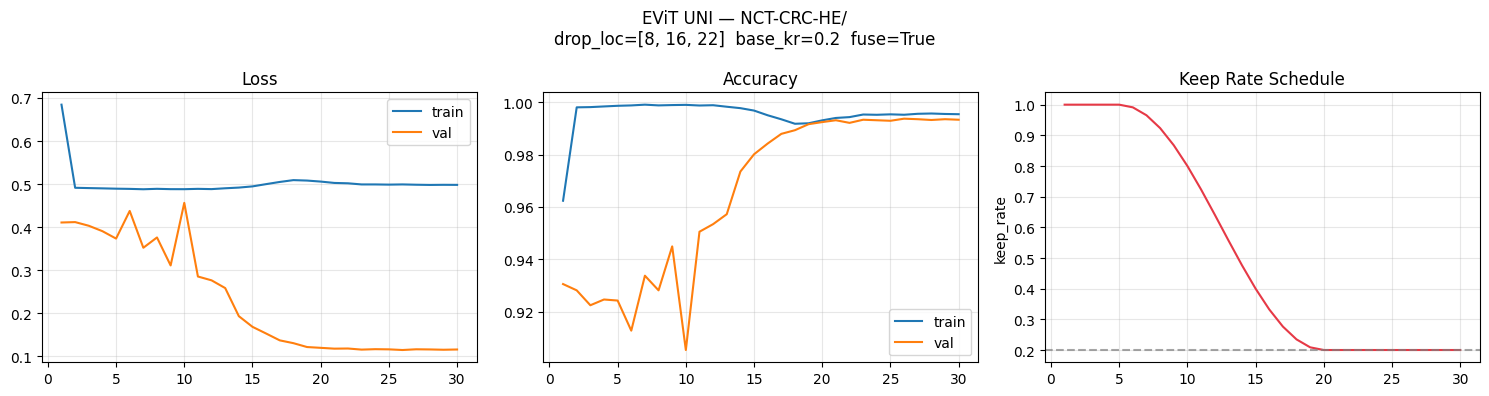

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ep = range(1, len(history["train_loss"]) + 1)
axes[0].plot(ep, history["train_loss"], label="train")
axes[0].plot(ep, history["val_loss"],   label="val")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(ep, history["train_acc"], label="train")
axes[1].plot(ep, history["val_acc"],   label="val")
axes[1].set_title("Accuracy"); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[2].plot(ep, history["keep_rate"], color="#e63946")
axes[2].axhline(CFG["base_keep_rate"], ls="--", color="gray", alpha=0.7)
axes[2].set_title("Keep Rate Schedule"); axes[2].set_ylabel("keep_rate")
axes[2].grid(alpha=0.3)
plt.suptitle(f"EViT UNI — {DATASET_NAME}\n"
             f"drop_loc={CFG['drop_loc']}  base_kr={CFG['base_keep_rate']}  "
             f"fuse={CFG['fuse_token']}")
plt.tight_layout()
plt.savefig(CFG["output_dir"] / "training_curves.png", dpi=150)
plt.show()

## 10 · Valutazione Test Set

In [11]:
model.load_state_dict(
    torch.load(CFG["output_dir"] / "best_model.pt", map_location=device)
)
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, lbls in tqdm(test_loader, desc="Test"):
        with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
            logits = model(imgs.to(device))
        all_preds.append(logits.float().argmax(1).cpu())
        all_labels.append(lbls)

all_preds  = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

acc      = float((all_preds == all_labels).mean())
f1_macro = float(f1_score(all_labels, all_preds, average="macro", zero_division=0))
print(f"Test accuracy : {acc:.4f}  |  F1 macro : {f1_macro:.4f}")
print()
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

Test:   0%|          | 0/898 [00:00<?, ?it/s]

Test accuracy : 0.7852  |  F1 macro : 0.7455

              precision    recall  f1-score   support

         ADI       1.00      0.70      0.82      1338
        BACK       0.97      0.34      0.50       847
         DEB       0.34      0.91      0.50       339
         LYM       0.99      0.90      0.94       634
         MUC       0.95      0.93      0.94      1035
         MUS       0.53      0.71      0.61       592
        NORM       0.85      0.94      0.89       741
         STR       0.58      0.62      0.60       421
         TUM       0.85      0.98      0.91      1233

    accuracy                           0.79      7180
   macro avg       0.79      0.78      0.75      7180
weighted avg       0.85      0.79      0.79      7180



## 11 · Confusion Matrix

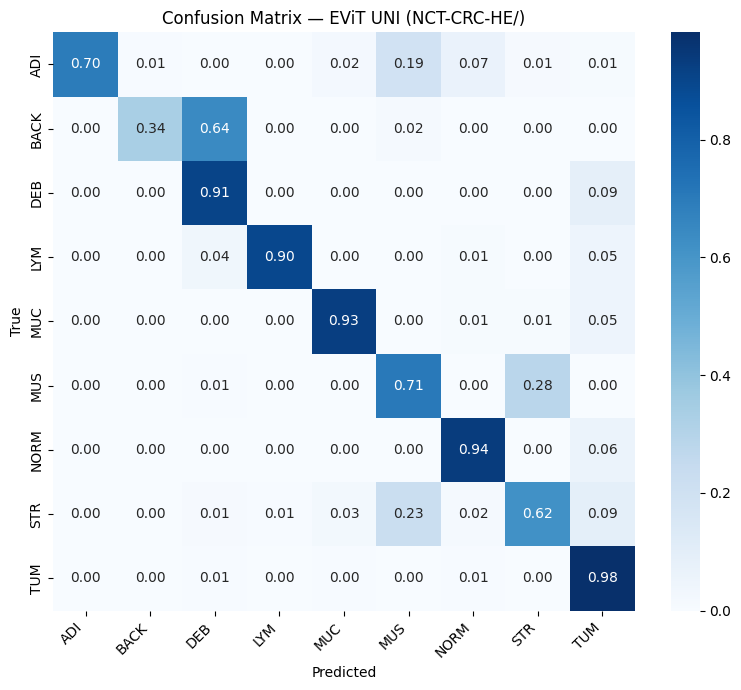

In [12]:
cm = confusion_matrix(all_labels, all_preds, normalize="true")
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"Confusion Matrix — EViT UNI ({DATASET_NAME})")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(CFG["output_dir"] / "confusion_matrix.png", dpi=150)
wandb.log({"confusion_matrix": wandb.Image(fig)})
plt.show()

## 12 · Token Budget

Token budget (inference, keep_rate=0.2, fuse=True):
  Ingresso    : 196
  Dopo blocco  8  : 41 token  (kept=40 + 1 fused)
  Dopo blocco 16  : 10 token  (kept=40 + 1 fused)
  Dopo blocco 22  : 3 token  (kept=40 + 1 fused)
  Finale      : 3 token
  Riduzione   : 1.5%


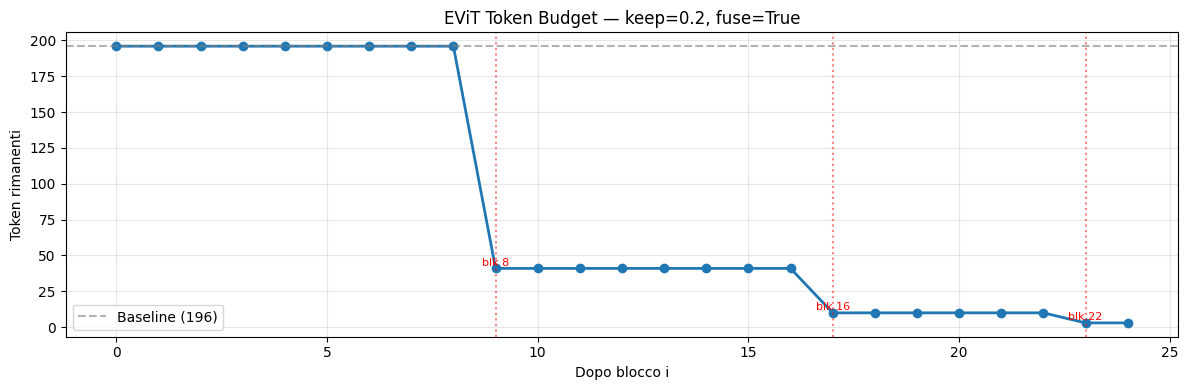

In [13]:
num_patches = (CFG["img_size"] // CFG["patch_size"]) ** 2
fuse_extra  = 1 if CFG["fuse_token"] else 0

tokens_per_layer = [num_patches]
for i in range(CFG["depth"]):
    prev = tokens_per_layer[-1]
    if i in CFG["drop_loc"]:
        kept  = math.ceil(prev * CFG["base_keep_rate"])
        tokens_per_layer.append(kept + fuse_extra)
    else:
        tokens_per_layer.append(prev)

print(f"Token budget (inference, keep_rate={CFG['base_keep_rate']}, fuse={CFG['fuse_token']}):")
print(f"  Ingresso    : {num_patches}")
for loc in CFG["drop_loc"]:
    n = tokens_per_layer[loc + 1]
    print(f"  Dopo blocco {loc:2d}  : {n} token  (kept={math.ceil(num_patches * CFG['base_keep_rate'])}"
          f" + {'1 fused' if CFG['fuse_token'] else 'no fused'})")
print(f"  Finale      : {tokens_per_layer[-1]} token")
print(f"  Riduzione   : {tokens_per_layer[-1]/num_patches:.1%}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(range(CFG["depth"] + 1), tokens_per_layer, marker="o", lw=2)
ax.axhline(num_patches, ls="--", color="gray", alpha=0.6, label=f"Baseline ({num_patches})")
for loc in CFG["drop_loc"]:
    ax.axvline(loc + 1, ls=":", color="red", alpha=0.5)
    ax.text(loc + 1, tokens_per_layer[loc + 1] + 2, f"blk {loc}",
            ha="center", fontsize=8, color="red")
ax.set_xlabel("Dopo blocco i")
ax.set_ylabel("Token rimanenti")
ax.set_title(f"EViT Token Budget — keep={CFG['base_keep_rate']}, fuse={CFG['fuse_token']}")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(CFG["output_dir"] / "token_budget.png", dpi=150)
plt.show()

## 13 · Salvataggio finale & WandB

In [14]:
wandb.log({"test/accuracy": acc, "test/f1_macro": f1_macro})
wandb.summary.update({"test/accuracy": acc, "test/f1_macro": f1_macro})
wandb.finish()
print(f"Test accuracy : {acc:.4f}  |  F1 macro : {f1_macro:.4f}")
print(f"Checkpoint    : {CFG['output_dir'] / 'best_model.pt'}")

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
keep_rate,███████▇▇▆▆▅▄▃▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
lr,▃▆█████▇▇▇▇▆▆▆▅▅▄▄▃▃▃▂▂▂▂▁▁▁▁▁
test/accuracy,▁
test/f1_macro,▁
train/acc,▁██████████████▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇
train/loss,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂▂▂▁▁▁▁▁▁▁▁▁
val/acc,▃▃▂▃▂▂▃▃▄▁▅▅▅▆▇▇██████████████
val/loss,▇▇▇▇▆█▆▆▅█▄▄▄▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_epoch,26
best_val_acc,0.9937


Test accuracy : 0.7852  |  F1 macro : 0.7455
Checkpoint    : /data/checkpoints-Attention-Pruning/NCT-CRC-HE/uni_evit/best_model.pt
